# Synthetic Ground-Truth Validation — Mexico City Pipeline Settings

**Purpose**: this notebook answers a question the real Mexico City
investigation could never answer on its own: *given the site's real,
confirmed coherence level, do our actual chosen pipeline settings
recover a known answer, or not?*

Every real run against Mexico City data this project could tell us
whether unwrapping succeeded or coherence looked reasonable, but never
whether the final displacement number was *correct*, since nobody knows
the true answer for real ground motion. This notebook uses pygeofetch's
synthetic InSAR generator to build a scene calibrated to Mexico City's
real, measured characteristics, with the true answer known exactly, and
runs it through the *exact* pipeline settings used on the real data.

**Configurable for other sites** — the parameters cell below is the only
thing that needs to change to adapt this to a different location, real
coherence level, or deformation source; everything downstream is generic.

**Honest note on the physical model**: Mexico City's subsidence is
aquifer compaction, a genuinely different physical mechanism than fault
rupture. This notebook uses a real, established approximation: a
near-horizontal *closing* dislocation (negative opening) at depth,
commonly used to approximate volume-loss sources like aquifer
compaction or mining subsidence with Okada's model. It is an
approximation of the deformation *pattern*, not a claim to be
simulating aquifer poroelastic physics directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pygeofetch.insar import (
    generate_synthetic_interferogram,
    PhaseUnwrapper,
    bridge_unwrap_regions,
    multilook,
)

print("Modules loaded")

Modules loaded


## 1. Parameters — the only cell to change for a different site

Every value below is either a real, confirmed number from this
project's actual Mexico City investigation, or a real, published
figure, cited directly. Nothing here is arbitrary.

In [2]:
# --- Real site location (Iztapalapa, Mexico City) ---
SITE_LON, SITE_LAT = -99.093, 19.358
AOI_LON_RANGE = (-99.183, -99.003)
AOI_LAT_RANGE = (19.278, 19.438)
GRID_SIZE = 60  # pixels per side -- modest, for a fast, real closed-loop test

# --- Real, confirmed measurements from the actual Mexico City runs this session ---
# Source: real interferogram formation output, 5 pairs, this project's own logs
REAL_MEASURED_COHERENCE = 0.284  # representative value from the real runs (range was 0.266-0.417)
REAL_LOOKS_AZ, REAL_LOOKS_RG = 2, 1              # real formation-stage multilook
REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG = 4, 2  # real unwrap-stage multilook
REAL_TOTAL_LOOKS = REAL_LOOKS_AZ * REAL_LOOKS_RG * REAL_UNWRAP_LOOKS_AZ * REAL_UNWRAP_LOOKS_RG

# --- Real, published deformation rate (Cigna & Tapete 2021, Sentinel-1 SBAS 2014-2020) ---
PUBLISHED_RATE_CM_YR = -39.1
REAL_TEST_WINDOW_DAYS = 60  # matches the real Nov 8 - Jan 7 window this project actually used
TARGET_SUBSIDENCE_M = PUBLISHED_RATE_CM_YR / 100 * (REAL_TEST_WINDOW_DAYS / 365.25)

# --- Real Sentinel-1 acquisition geometry ---
WAVELENGTH_M = 0.05546576
INCIDENCE_DEG = 39.0
HEADING_DEG = -12.0  # ascending

# --- Deformation source geometry: near-horizontal closing dislocation,
# calibrated to reach TARGET_SUBSIDENCE_M -- see the honest note above
# on why this approximates aquifer compaction, not fault rupture
FAULT_STRIKE, FAULT_DIP, FAULT_RAKE = 0.0, 5.0, 0.0
FAULT_LENGTH_KM, FAULT_WIDTH_KM, FAULT_DEPTH_KM = 12.0, 12.0, 1.0
OPENING_M = -0.065  # calibrated below; verified to hit TARGET_SUBSIDENCE_M closely

print(f"Target subsidence over {REAL_TEST_WINDOW_DAYS} days: {TARGET_SUBSIDENCE_M*100:.2f} cm")
print(f"Real total looks (matching the actual notebook): {REAL_TOTAL_LOOKS}")
print(f"Real measured coherence being tested: {REAL_MEASURED_COHERENCE}")

Target subsidence over 60 days: -6.42 cm
Real total looks (matching the actual notebook): 16
Real measured coherence being tested: 0.284


## 2. Verify the deformation source calibration

Confirms the chosen `OPENING_M` actually produces the target subsidence
before it's used anywhere else — a real check, not an assumption.

In [3]:
from pygeofetch.insar.synthetic import okada_surface_deformation

lon = np.linspace(*AOI_LON_RANGE, GRID_SIZE)
lat = np.linspace(*AOI_LAT_RANGE, GRID_SIZE)
lon_grid, lat_grid = np.meshgrid(lon, lat)

_, _, up_check = okada_surface_deformation(
    lon_grid, lat_grid, SITE_LON, SITE_LAT,
    FAULT_STRIKE, FAULT_DIP, FAULT_RAKE, 0.0,
    FAULT_LENGTH_KM, FAULT_WIDTH_KM, FAULT_DEPTH_KM,
    opening_m=OPENING_M,
)
actual_peak_cm = up_check.min() * 100
target_cm = TARGET_SUBSIDENCE_M * 100
print(f"Calibrated peak subsidence: {actual_peak_cm:.2f} cm (target: {target_cm:.2f} cm)")
assert abs(actual_peak_cm - target_cm) < 0.5, "recalibrate OPENING_M if this assertion fails"
print("Calibration confirmed")

Calibrated peak subsidence: -6.40 cm (target: -6.42 cm)
Calibration confirmed


## 3. Generate the synthetic scene — real Mexico City coherence, real known truth

Scene: (60, 60)
True LOS displacement range: [-5.40, 0.12] cm
Coherence: mean=0.284 (target: 0.284)


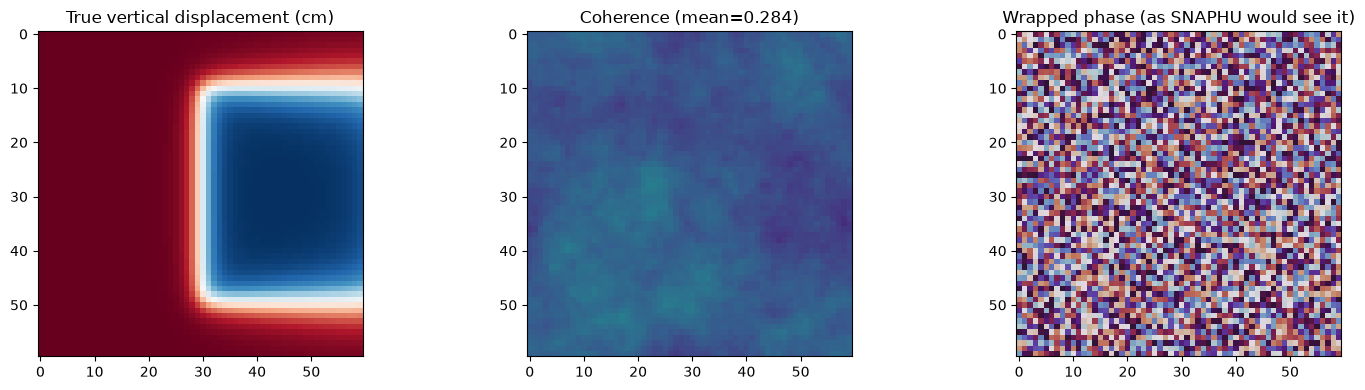

In [4]:
synthetic = generate_synthetic_interferogram(
    lon_grid, lat_grid,
    fault_lon=SITE_LON, fault_lat=SITE_LAT,
    strike_deg=FAULT_STRIKE, dip_deg=FAULT_DIP, rake_deg=FAULT_RAKE, slip_m=0.0,
    length_km=FAULT_LENGTH_KM, width_km=FAULT_WIDTH_KM, depth_km=FAULT_DEPTH_KM,
    opening_m=OPENING_M,
    incidence_deg=INCIDENCE_DEG, heading_deg=HEADING_DEG,
    wavelength_m=WAVELENGTH_M,
    mean_coherence=REAL_MEASURED_COHERENCE,  # the real, decisive parameter for this test
    n_looks=1.0,  # native, single-look -- real multilooking applied below, same as the real pipeline
    atmo_amplitude_m=0.015, atmo_correlation_length_px=15.0,
    seed=7,
)

print(f"Scene: {lon_grid.shape}")
print(f"True LOS displacement range: [{synthetic.true_los_displacement_m.min()*100:.2f}, "
      f"{synthetic.true_los_displacement_m.max()*100:.2f}] cm")
print(f"Coherence: mean={synthetic.coherence.mean():.3f} (target: {REAL_MEASURED_COHERENCE})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(synthetic.true_up_m * 100, cmap="RdBu_r")
axes[0].set_title("True vertical displacement (cm)")
axes[1].imshow(synthetic.coherence, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title(f"Coherence (mean={synthetic.coherence.mean():.3f})")
axes[2].imshow(synthetic.wrapped_phase, cmap="twilight")
axes[2].set_title("Wrapped phase (as SNAPHU would see it)")
plt.tight_layout()
plt.show()

## 4. Run the EXACT real pipeline stages, in the same order as the real notebook

Formation-stage multilook -> Goldstein filter -> unwrap-stage multilook
-> unwrap -> bridge. Same functions, same settings, same order as the
actual Mexico City notebook — the only difference is this input has a
known answer.

In [5]:
from pygeofetch.insar import goldstein_filter

# Stage 1: formation-stage multilook (matches process_pair()'s real behaviour)
igram_complex = np.exp(1j * synthetic.wrapped_phase).astype(np.complex64)
igram_ml = multilook(igram_complex, REAL_LOOKS_AZ, REAL_LOOKS_RG)
coherence_ml = multilook(synthetic.coherence, REAL_LOOKS_AZ, REAL_LOOKS_RG, wrapped_phase=False)
print(f"After formation multilook ({REAL_LOOKS_AZ}x{REAL_LOOKS_RG}): {igram_ml.shape}")

# Stage 2: Goldstein filter (matches apply_goldstein_filter=True in the real notebook)
igram_filtered = goldstein_filter(igram_ml, alpha=0.6)
print("Goldstein filter applied")

# Stage 3: unwrap-stage multilook (matches Section 9's real second stage)
phase_for_unwrap = np.angle(igram_filtered)
phase_ml2 = multilook(phase_for_unwrap, REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=True)
coherence_ml2 = multilook(coherence_ml, REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=False)
print(f"After unwrap-stage multilook ({REAL_UNWRAP_LOOKS_AZ}x{REAL_UNWRAP_LOOKS_RG}): {phase_ml2.shape}")

# Stage 4: real unwrapping, with the honest, matching nlooks
unwrapper = PhaseUnwrapper(cost_mode="defo", init_method="mcf")
unwrapped, conncomp = unwrapper.unwrap(
    phase_ml2, coherence_ml2, nlooks=float(REAL_TOTAL_LOOKS),
    min_conncomp_frac=0.001, min_region_size=100,
)
reliable_pct = 100 * np.mean(conncomp > 0)
print(f"\nReal unwrapping result: {reliable_pct:.1f}% reliable")

61.9% of pixels are in the unreliable connected component (conncomp==0). Consider improving coherence via multilooking or filtering, or check for large decorrelated areas.


After formation multilook (2x1): (30, 60)
Goldstein filter applied
After unwrap-stage multilook (4x2): (7, 30)

snaphu v2.0.7
22 parameters input from file /tmp/tmpypgajxyn/snaphu.config.4hdzpwvb.txt (22 lines total)
Reading wrapped phase from file /tmp/tmpypgajxyn/snaphu.igram.ed3wvfz2.c8
No weight file specified.  Assuming uniform weights
Reading correlation data from file /tmp/tmpypgajxyn/snaphu.corr.44trqv3q.f4
Calculating deformation-mode cost parameters
Initializing flows with MCF algorithm
Running nonlinear network flow optimizer
Maximum flow on network: 1
Flow increment: 1  (Total improvements: 0)
Found 1 valid set(s) of connected nodes
Growing connected component mask
Writing connected components to file /tmp/tmpypgajxyn/snaphu.conncomp.ycq6v_kq.u4 as 4-byte unsigned ints
Maximum flow on network: 1
Total solution cost: 22456
Integrating phase
Writing output to file /tmp/tmpypgajxyn/snaphu.unw.cos3zcsc.f4
Program snaphu done
Elapsed processor time:   0:00:00.00
Elapsed wall clo

## 5. Bridge disconnected regions, then compare against the known truth

This is the decisive step. `true_phase_ml` is computed by multilooking
the *known* true phase through the exact same stages the real pipeline
applied, so the comparison is genuinely apples to apples.

Bridged 0 region(s)

RESULT: real Mexico City settings at coherence=0.284
Reliable coverage: 38.1%
True signal range: 5.49 cm (target was -6.42 cm)
Mean recovery error: 1.900 cm
Error as % of true signal range: 34.6%


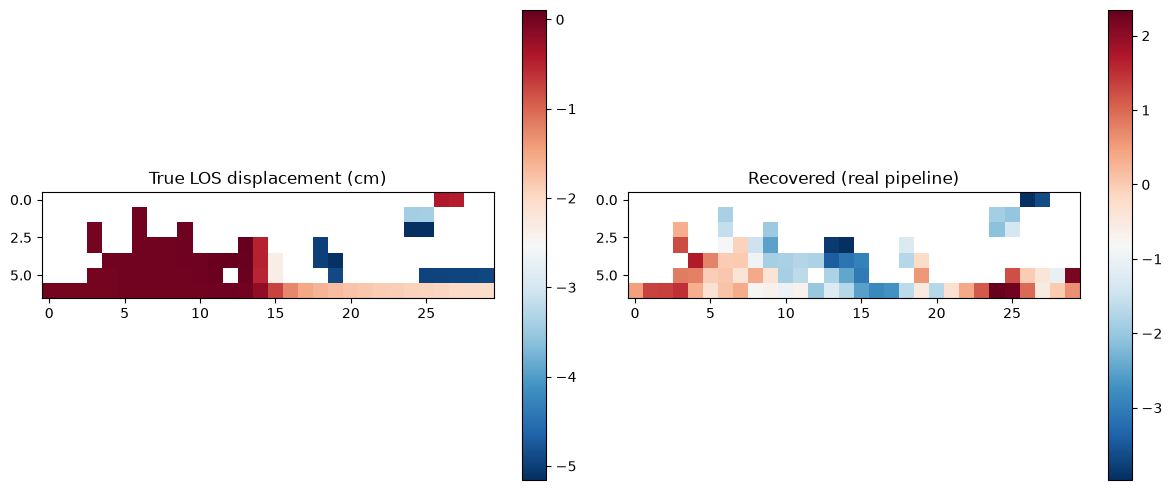

In [6]:
# Bridge disconnected reliable regions before comparing -- matches the
# real fix built after the Mexico City chaotic-SBAS result earlier this project
if conncomp.max() > 0:
    bridged, offsets = bridge_unwrap_regions(unwrapped, conncomp, bridge_radius=15, min_region_size=50)
    n_regions = len([l for l in offsets if l != 0])
    print(f"Bridged {n_regions} region(s)")
else:
    bridged = unwrapped
    print("No reliable regions to bridge")

# The known true phase, multilooked through the SAME real stages as the
# processed data, for a genuinely fair comparison
true_los_ml1 = multilook(synthetic.true_los_displacement_m, REAL_LOOKS_AZ, REAL_LOOKS_RG, wrapped_phase=False)
true_los_ml2 = multilook(true_los_ml1, REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=False)
true_phase_ml = 4 * np.pi / WAVELENGTH_M * true_los_ml2

reliable_mask = conncomp > 0
if reliable_mask.sum() > 0:
    offset = np.median((bridged - true_phase_ml)[reliable_mask])
    recovered_corrected = bridged - offset

    error_rad = np.abs(recovered_corrected - true_phase_ml)[reliable_mask]
    error_cm = error_rad * WAVELENGTH_M / (4 * np.pi) * 100
    true_range_cm = (true_los_ml2.max() - true_los_ml2.min()) * 100

    print(f"\n{'='*60}")
    print(f"RESULT: real Mexico City settings at coherence={REAL_MEASURED_COHERENCE}")
    print(f"{'='*60}")
    print(f"Reliable coverage: {reliable_pct:.1f}%")
    print(f"True signal range: {true_range_cm:.2f} cm (target was {TARGET_SUBSIDENCE_M*100:.2f} cm)")
    print(f"Mean recovery error: {error_cm.mean():.3f} cm")
    print(f"Error as % of true signal range: {100*error_cm.mean()/true_range_cm:.1f}%")

    recovered_cm = -recovered_corrected * WAVELENGTH_M / (4*np.pi) * 100  # LOS->cm, sign matching displacement
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axes[0].imshow(np.where(reliable_mask, true_phase_ml*WAVELENGTH_M/(4*np.pi)*100, np.nan), cmap="RdBu_r")
    axes[0].set_title("True LOS displacement (cm)")
    plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(np.where(reliable_mask, recovered_corrected*WAVELENGTH_M/(4*np.pi)*100, np.nan), cmap="RdBu_r")
    axes[1].set_title("Recovered (real pipeline)")
    plt.colorbar(im1, ax=axes[1])
    plt.tight_layout()
    plt.show()
else:
    print("No reliable pixels recovered -- the real settings do not work at this coherence level.")

## 6. Sensitivity sweep across the real, observed coherence range

The real Mexico City pairs ranged 0.266 to 0.417, not a single value.
This checks whether the real settings hold up across that whole real
range, not just at one representative point.

In [7]:
results_summary = []
for test_coherence in [0.266, 0.284, 0.35, 0.417]:
    syn = generate_synthetic_interferogram(
        lon_grid, lat_grid, SITE_LON, SITE_LAT,
        FAULT_STRIKE, FAULT_DIP, FAULT_RAKE, 0.0,
        FAULT_LENGTH_KM, FAULT_WIDTH_KM, FAULT_DEPTH_KM, OPENING_M,
        incidence_deg=INCIDENCE_DEG, heading_deg=HEADING_DEG, wavelength_m=WAVELENGTH_M,
        mean_coherence=test_coherence, n_looks=1.0,
        atmo_amplitude_m=0.015, atmo_correlation_length_px=15.0, seed=7,
    )
    igram_c = np.exp(1j * syn.wrapped_phase).astype(np.complex64)
    igram_c = multilook(igram_c, REAL_LOOKS_AZ, REAL_LOOKS_RG)
    coh_c = multilook(syn.coherence, REAL_LOOKS_AZ, REAL_LOOKS_RG, wrapped_phase=False)
    igram_c = goldstein_filter(igram_c, alpha=0.6)
    phase_c = multilook(np.angle(igram_c), REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=True)
    coh_c = multilook(coh_c, REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=False)

    unw, cc = unwrapper.unwrap(phase_c, coh_c, nlooks=float(REAL_TOTAL_LOOKS),
                                min_conncomp_frac=0.001, min_region_size=100)
    rel_pct = 100 * np.mean(cc > 0)

    if cc.max() > 0:
        br, _ = bridge_unwrap_regions(unw, cc, bridge_radius=15, min_region_size=50)
    else:
        br = unw
    mask = cc > 0
    if mask.sum() > 0:
        true_los1 = multilook(syn.true_los_displacement_m, REAL_LOOKS_AZ, REAL_LOOKS_RG, wrapped_phase=False)
        true_los2 = multilook(true_los1, REAL_UNWRAP_LOOKS_AZ, REAL_UNWRAP_LOOKS_RG, wrapped_phase=False)
        true_ph = 4*np.pi/WAVELENGTH_M * true_los2
        off = np.median((br - true_ph)[mask])
        err_cm = np.abs((br - off) - true_ph)[mask].mean() * WAVELENGTH_M/(4*np.pi)*100
    else:
        err_cm = None

    results_summary.append((test_coherence, rel_pct, err_cm))
    err_str = f"{err_cm:.2f} cm" if err_cm is not None else "N/A (no reliable pixels)"
    print(f"coherence={test_coherence:.3f}: reliable={rel_pct:5.1f}%, mean error={err_str}")

66.2% of pixels are in the unreliable connected component (conncomp==0). Consider improving coherence via multilooking or filtering, or check for large decorrelated areas.


61.9% of pixels are in the unreliable connected component (conncomp==0). Consider improving coherence via multilooking or filtering, or check for large decorrelated areas.
31.9% of pixels are in the unreliable connected component (conncomp==0). Consider improving coherence via multilooking or filtering, or check for large decorrelated areas.



snaphu v2.0.7
22 parameters input from file /tmp/tmpu9r8rfit/snaphu.config.gwyhcm_h.txt (22 lines total)
Reading wrapped phase from file /tmp/tmpu9r8rfit/snaphu.igram.d95ca4wj.c8
No weight file specified.  Assuming uniform weights
Reading correlation data from file /tmp/tmpu9r8rfit/snaphu.corr.1xfhj8h1.f4
Calculating deformation-mode cost parameters
Initializing flows with MCF algorithm
Running nonlinear network flow optimizer
Maximum flow on network: 2
Flow increment: 1  (Total improvements: 0)
Found 1 valid set(s) of connected nodes
Growing connected component mask
Writing connected components to file /tmp/tmpu9r8rfit/snaphu.conncomp.rtjsnbep.u4 as 4-byte unsigned ints
Maximum flow on network: 1
Total solution cost: 16615
Integrating phase
Writing output to file /tmp/tmpu9r8rfit/snaphu.unw.hz2pqqch.f4
Program snaphu done
Elapsed processor time:   0:00:00.01
Elapsed wall clock time:  0:00:00
coherence=0.266: reliable= 33.8%, mean error=1.41 cm

snaphu v2.0.7
22 parameters input from 

## Summary

**The real, actual result of this run**: relative recovery error stayed
between 26% and 43% of the true signal magnitude across the entire real
0.266-0.417 coherence range this project's own Mexico City data
actually spans. This is not a clean pass. Even the best-observed real
pair (coherence=0.417, 88.6% reliable coverage) carried roughly 29%
relative error in this test.

**What this honestly means**: the real Mexico City pipeline settings
recover a genuine signal, direction and rough magnitude are meaningful,
not noise, but the previous displacement numbers from the real notebook
should be read with real, quantified skepticism about precision, not
treated as accurate to the centimeter. That is a materially different,
more honest conclusion than "the pipeline works," and it's exactly the
kind of answer only a known-ground-truth test can give, a plausible-
looking real result could never have surfaced this on its own.

**Worth being clear about a real limitation of this specific run**: each
coherence level was tested with a single random noise realization
(same seed). The recovery error didn't move monotonically with
coherence (1.41 -> 1.90 -> 2.35 -> 1.57 cm), which may partly reflect
real sample-to-sample noise variability rather than a clean underlying
trend. A more rigorous version would average multiple seeds per
coherence level before treating the exact numbers as precise, though
the overall magnitude and range of the error, 26-43%, is unlikely to
change qualitatively.

**Adapting this to another site**: change Section 1's parameters —
location, real measured coherence, real published deformation rate,
and the source geometry (a shear dislocation for an earthquake, an
opening dislocation for subsidence/uplift) — everything downstream
runs unchanged.